In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
print('GPU 사용 가능 여부:', torch.cuda.is_available())

GPU 사용 가능 여부: True


In [3]:
# 1. 주피터 노트북 내부 출력 설정 및 폰트 음수 깨짐 방지
%matplotlib inline
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# 2. 데이터 생성
X = torch.randn(200, 1)
Y = 3 * (X ** 2) - (2 * X) + torch.randn(200, 1) * 0.5

# 3. 2차 다항식으로 변환
X_ploy = torch.cat((X, X ** 2), dim=1) # 차원 (200, 2)
print(X_ploy.shape)


torch.Size([200, 2])


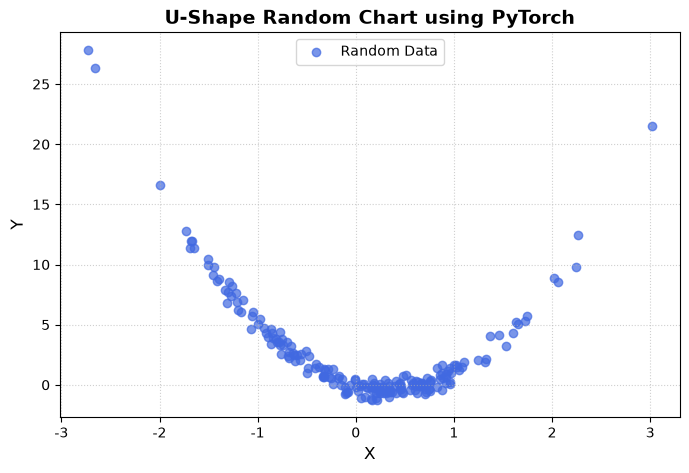

In [5]:
# 5. 차트 그리기
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), Y.numpy(), color='royalblue', alpha=0.7, label='Random Data') # 산점도

# 차트 스타일링
plt.title('U-Shape Random Chart using PyTorch', fontsize=14, fontweight='bold')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.legend(loc='upper center')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

### 모델 클래스 생성

In [6]:
class LenearRegressionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        self.layer1 = torch.nn.Linear(in_features=2, out_features=2)
        self.layer2 = torch.nn.Linear(2, 1)
        self.act = torch.nn.Sigmoid()
        
    def forward(self, x):
        x = self.layer1(x)
        # x = self.act(x)
        x = self.layer2(x)
        
        return x

model = LenearRegressionModel()

In [7]:
print(model)

LenearRegressionModel(
  (layer1): Linear(in_features=2, out_features=2, bias=True)
  (layer2): Linear(in_features=2, out_features=1, bias=True)
  (act): Sigmoid()
)


In [8]:
# 손실함수, 옵티마이저 설정
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)

In [9]:
losses = []
epochs = 2000

for t in range(epochs):
    # 순전파 단계: 모델에 x를 전달하여 예측값 y를 계산합니다.
    y_pred = model(X_ploy)

    # 손실을 계산하고 추가
    loss = criterion(y_pred, Y)
    losses.append(loss.item())

    # 변화도를 0으로 만들고, 역전파 단계를 수행하고, 가중치를 갱신합니다.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



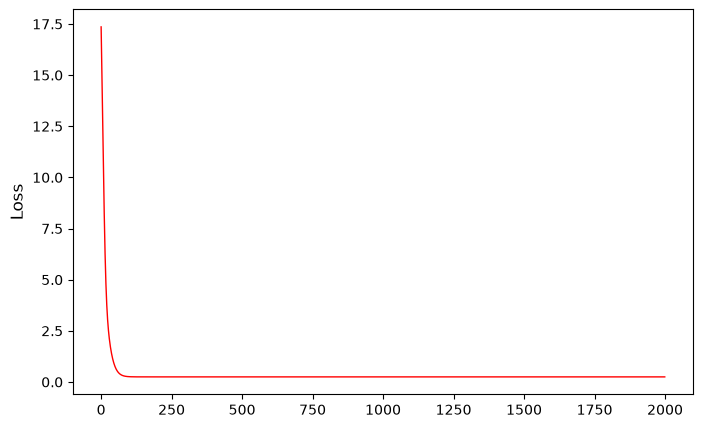

In [10]:
# Loss 변화 차트
plt.figure(figsize=(8, 5))
plt.plot(range(epochs), losses, color='red', linestyle='-', linewidth=1, label='Loss')
plt.ylabel('Loss', fontsize=12)

plt.show()

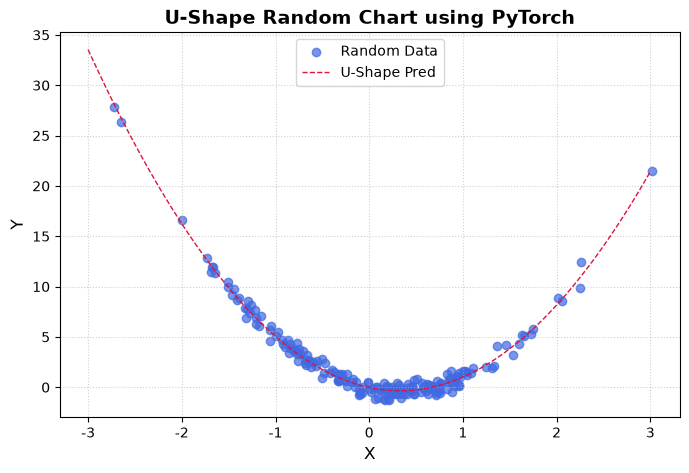

In [11]:
# 학습 완료 후 차트
# 시각화를 위한 촘촘한 x 데이터 생성
x_range = torch.linspace(-3, 3, 100).reshape(-1, 1)
x_range_poly = torch.cat((x_range, x_range ** 2), dim=1)
y_pred = model(x_range_poly)

# 모델을 평가 모드로 전환 후 예측값 계산 (기울기 계산 불필요)
model.eval()
with torch.no_grad():
    y_pred_range = model(x_range_poly)

# 차트 그리기
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), Y.numpy(), color='royalblue', alpha=0.7, label='Random Data') # 산점도
plt.plot(x_range.numpy(), y_pred_range.detach().numpy(), color='crimson', linestyle='--', linewidth=1, label='U-Shape Pred') # 기준선

# 차트 스타일링
plt.title('U-Shape Random Chart using PyTorch', fontsize=14, fontweight='bold')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.legend(loc='upper center')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()